In [1]:
# Cell 1: Imports, project paths and data loading
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn

# Resolve the project root whether the notebook runs from /notebooks or the root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "hotels.csv"
FIG_DIR = ROOT / "figures"
TAB_DIR = ROOT / "tables"

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

df = pd.read_csv(DATA_RAW)

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")
print(f"seaborn      : {sns.__version__}")
print(f"\nProject root : {ROOT}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Python       : 3.14.7
pandas       : 3.0.6
numpy        : 2.5.3
scikit-learn : 1.9.1
matplotlib   : 3.11.2
seaborn      : 0.13.2

Project root : c:\Users\Zen\Documents\INTI\6001CMD MLARA\Individual Assignment\6001CMD-hotel-booking-ml
Dataset shape: 119,390 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
# Cell 2: Feature overview table (Table 1.1)
# Descriptions follow the dataset's source paper (Antonio, de Almeida & Nunes, 2019)
feature_info = {
    "hotel": ("Categorical", "Hotel type: City Hotel or Resort Hotel"),
    "is_canceled": ("Target (binary)", "1 if the booking was cancelled, 0 otherwise"),
    "lead_time": ("Numerical", "Days between booking entry and arrival date"),
    "arrival_date_year": ("Temporal", "Year of arrival"),
    "arrival_date_month": ("Temporal", "Month of arrival"),
    "arrival_date_week_number": ("Temporal", "Week number of arrival"),
    "arrival_date_day_of_month": ("Temporal", "Day of month of arrival"),
    "stays_in_weekend_nights": ("Numerical", "Weekend nights (Sat/Sun) stayed or booked"),
    "stays_in_week_nights": ("Numerical", "Weeknights (Mon to Fri) stayed or booked"),
    "adults": ("Numerical", "Number of adults"),
    "children": ("Numerical", "Number of children"),
    "babies": ("Numerical", "Number of babies"),
    "meal": ("Categorical", "Meal package booked (BB, HB, FB, SC, Undefined)"),
    "country": ("Categorical", "Country of origin (ISO 3166-1 alpha-3)"),
    "market_segment": ("Categorical", "Market segment (e.g. Online TA, Groups)"),
    "distribution_channel": ("Categorical", "Booking distribution channel"),
    "is_repeated_guest": ("Binary", "1 if the guest has stayed before, 0 otherwise"),
    "previous_cancellations": ("Numerical", "Prior bookings cancelled by the customer"),
    "previous_bookings_not_canceled": ("Numerical", "Prior bookings not cancelled by the customer"),
    "reserved_room_type": ("Categorical", "Room type code reserved (anonymised)"),
    "assigned_room_type": ("Categorical", "Room type code assigned at check-in (anonymised)"),
    "booking_changes": ("Numerical", "Amendments made before check-in or cancellation"),
    "deposit_type": ("Categorical", "Deposit type: No Deposit, Non Refund, Refundable"),
    "agent": ("Categorical", "Travel agency ID (anonymised)"),
    "company": ("Categorical", "Paying company ID (anonymised)"),
    "days_in_waiting_list": ("Numerical", "Days on the waiting list before confirmation"),
    "customer_type": ("Categorical", "Contract, Group, Transient or Transient-Party"),
    "adr": ("Numerical", "Average daily rate (lodging revenue / nights)"),
    "required_car_parking_spaces": ("Numerical", "Car parking spaces requested"),
    "total_of_special_requests": ("Numerical", "Number of special requests made"),
    "reservation_status": ("Post-outcome (leakage)", "Final status: Canceled, Check-Out or No-Show"),
    "reservation_status_date": ("Post-outcome (leakage)", "Date the final status was recorded"),
}

rows = []
for col in df.columns:
    ftype, desc = feature_info[col]
    s = df[col]
    rows.append({
        "Feature": col,
        "Type": ftype,
        "Pandas dtype": str(s.dtype),
        "Unique values": f"{s.nunique(dropna=True):,}",
        "Missing": f"{int(s.isna().sum()):,}",
        "Example": s.dropna().iloc[0],
        "Description": desc,
    })

table_1_1 = pd.DataFrame(rows)
table_1_1.to_csv(TAB_DIR / "table1.1_feature_overview.csv", index=False)

print("Feature count by type:")
print(table_1_1["Type"].value_counts().to_string())

print("\nFeatures with missing values:")
missing = df.isna().sum()
print(missing[missing > 0].to_string())

print(f"\nSaved: {TAB_DIR / 'table1.1_feature_overview.csv'}")
table_1_1

Feature count by type:
Type
Numerical                 13
Categorical               11
Temporal                   4
Post-outcome (leakage)     2
Target (binary)            1
Binary                     1

Features with missing values:
children         4
country        488
agent        16340
company     112593

Saved: c:\Users\Zen\Documents\INTI\6001CMD MLARA\Individual Assignment\6001CMD-hotel-booking-ml\tables\table1.1_feature_overview.csv


,Feature,Type,Pandas dtype,Unique values,Missing,Example,Description
0,hotel,Categorical,str,2,0,Resort Hotel,Hotel type: City Hotel or Resort Hotel
1,is_canceled,Target (binary),int64,2,0,0,"1 if the booking was cancelled, 0 otherwise"
2,lead_time,Numerical,int64,479,0,342,Days between booking entry and arrival date
3,arrival_date_year,Temporal,int64,3,0,2015,Year of arrival
4,arrival_date_month,Temporal,str,12,0,July,Month of arrival
5,arrival_date_week_number,Temporal,int64,53,0,27,Week number of arrival
6,arrival_date_day_of_month,Temporal,int64,31,0,1,Day of month of arrival
7,stays_in_weekend_nights,Numerical,int64,17,0,0,Weekend nights (Sat/Sun) stayed or booked
8,stays_in_week_nights,Numerical,int64,35,0,0,Weeknights (Mon to Fri) stayed or booked
9,adults,Numerical,int64,14,0,2,Number of adults


Target variable: is_canceled
  0 (Not cancelled): 75,166 bookings (62.96%)
  1 (Cancelled): 44,224 bookings (37.04%)
  Imbalance ratio (majority:minority): 1.70:1


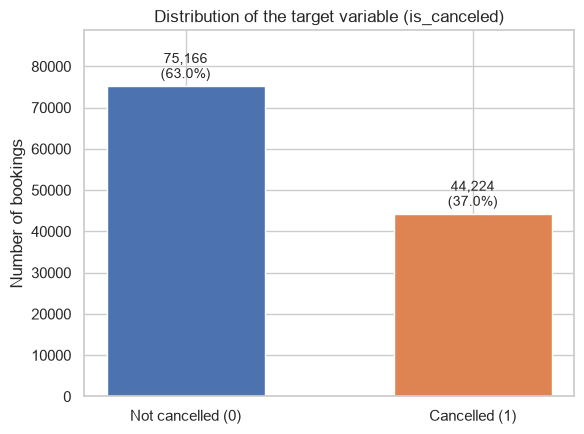


Cancellation rate by hotel type:
  Hotel type Bookings Cancelled  Cancellation rate (%)
  City Hotel   79,330    33,102                  41.73
Resort Hotel   40,060    11,122                  27.76


In [6]:
# Cell 3: Target variable distribution (Figure 1.1, Table 1.2)
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Class counts and proportions
target_counts = df["is_canceled"].value_counts().sort_index()
target_pct = df["is_canceled"].value_counts(normalize=True).sort_index() * 100
print("Target variable: is_canceled")
for cls in target_counts.index:
    label = "Cancelled" if cls == 1 else "Not cancelled"
    print(f"  {cls} ({label}): {target_counts[cls]:,} bookings ({target_pct[cls]:.2f}%)")
print(f"  Imbalance ratio (majority:minority): {target_counts.max() / target_counts.min():.2f}:1")

# Figure 1.1: class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Not cancelled (0)", "Cancelled (1)"], target_counts.values,
              color=["#4C72B0", "#DD8452"], width=0.55)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of bookings")
ax.set_title("Distribution of the target variable (is_canceled)")
ax.set_ylim(0, target_counts.max() * 1.18)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1.1_target_distribution.png", dpi=300)
plt.show()

# Table 1.2: cancellation rate by hotel type
summary = df.groupby("hotel")["is_canceled"].agg(["count", "sum", "mean"]).reset_index()
table_1_2 = pd.DataFrame({
    "Hotel type": summary["hotel"],
    "Bookings": summary["count"].map("{:,}".format),
    "Cancelled": summary["sum"].map("{:,}".format),
    "Cancellation rate (%)": (summary["mean"] * 100).round(2),
})
table_1_2.to_csv(TAB_DIR / "table1.2_cancellation_by_hotel.csv", index=False)
print("\nCancellation rate by hotel type:")
print(table_1_2.to_string(index=False))

In [4]:
# Cell 4: Dataset challenge scan (Table 1.3)
month_map = {m: i for i, m in enumerate(
    ["January", "February", "March", "April", "May", "June", "July",
     "August", "September", "October", "November", "December"], start=1)}

arrival = pd.to_datetime(pd.DataFrame({
    "year": df["arrival_date_year"],
    "month": df["arrival_date_month"].map(month_map),
    "day": df["arrival_date_day_of_month"],
}))

total_guests = df["adults"] + df["children"].fillna(0) + df["babies"]
total_nights = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
n = len(df)

def pct(x):
    return f"{x:,} ({x / n * 100:.2f}%)"

challenges = [
    ("Arrival period covered", f"{arrival.min().date()} to {arrival.max().date()}"),
    ("Exact duplicate rows", pct(int(df.duplicated().sum()))),
    ("Bookings with zero guests", pct(int((total_guests == 0).sum()))),
    ("Bookings with zero nights", pct(int((total_nights == 0).sum()))),
    ("Negative ADR values", pct(int((df["adr"] < 0).sum()))),
    ("ADR above 1,000", f"{int((df['adr'] > 1000).sum())} (max = {df['adr'].max():,.2f})"),
    ("Maximum lead_time (days)", f"{df['lead_time'].max()}"),
    ("meal recorded as 'Undefined'", pct(int((df["meal"] == "Undefined").sum()))),
    ("Unique country codes", f"{df['country'].nunique()}"),
    ("Unique agent IDs", f"{df['agent'].nunique()}"),
    ("Unique company IDs", f"{df['company'].nunique()}"),
    ("Assigned room differs from reserved", pct(int((df["assigned_room_type"] != df["reserved_room_type"]).sum()))),
]

table_1_3 = pd.DataFrame(challenges, columns=["Check", "Result"])
table_1_3.to_csv(TAB_DIR / "table1.3_challenge_scan.csv", index=False)
print("Dataset challenge scan:")
print(table_1_3.to_string(index=False))

# Leakage evidence: reservation_status against the target
print("\nLeakage check: reservation_status vs is_canceled")
print(pd.crosstab(df["reservation_status"], df["is_canceled"], margins=True))

Dataset challenge scan:
                              Check                   Result
             Arrival period covered 2015-07-01 to 2017-08-31
               Exact duplicate rows          31,994 (26.80%)
          Bookings with zero guests              180 (0.15%)
          Bookings with zero nights              715 (0.60%)
                Negative ADR values                1 (0.00%)
                    ADR above 1,000       1 (max = 5,400.00)
           Maximum lead_time (days)                      737
       meal recorded as 'Undefined'            1,169 (0.98%)
               Unique country codes                      177
                   Unique agent IDs                      333
                 Unique company IDs                      352
Assigned room differs from reserved          14,917 (12.49%)

Leakage check: reservation_status vs is_canceled
is_canceled             0      1     All
reservation_status                      
Canceled                0  43017   43017
Check-Out 